# Physarum (le blob) — classification MNIST sans neurones

On teste une architecture inspirée du **Physarum polycephalum** (le myxomycète / blob), un organisme sans neurones qui résout pourtant des problèmes (labyrinthe, optimisation de réseaux). Le changement de paradigme : **on ne calcule pas des matrices de poids, on modélise des dynamiques de flux**.

## Références scientifiques
- **Tero, Kobayashi, Nakagaki (2007)** — *A mathematical model for adaptive transport network in path finding by true slime mold*, J. Theoretical Biology. Le modèle de référence (loi de Poiseuille + conservation de Kirchhoff + adaptation des tubes).
- **Solé & Pla-Mauri (2025)** — *Cognition as least action: the Physarum Lagrangian*, arXiv:2511.08531. Formulation lagrangienne : les états stationnaires minimisent la dissipation d'énergie.

## Modèle mathématique
| Équation | Sens |
|---|---|
| $Q_{ij} = \frac{D_{ij}}{L_{ij}}(p_i - p_j)$ | **Poiseuille** : flux ∝ conductance × gradient de pression |
| $\sum_j Q_{ij} = S_i$ | **Kirchhoff** : conservation de la masse (injections $S_i$) |
| $\frac{dD_{ij}}{dt} = |Q_{ij}|^\mu - \delta D_{ij}$ | **Adaptation** : les tubes utilisés s'élargissent, les autres dépérissent |
| $P = \sum \frac{L_{ij}}{D_{ij}} Q_{ij}^2$ | **Dissipation** (Lagrangien) : le flux optimal minimise l'énergie |

## Idée de classification
Les pixels de l'image deviennent des **injections de pression** $S_i$. Le flux circule dans le graphe et adapte les tubes selon la forme. La classe est déduite de la **signature de flux** (comme un réservoir).

## 0. Imports

In [1]:
# Physarum (blob) sur MNIST — réseau de tubes adaptatif sans neurones
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (load_mnist, filter_by_digits, PhysarumGraph,
    grid_graph_from_image, classify_by_drainage)
from recherche_agi.physarum import poiseuille_flow, run_physarum, adapt_conductances

## 1. Données : MNIST

In [2]:
train_set, test_set = load_mnist()
print("Train :", len(train_set), "| Test :", len(test_set))

Train : 60000 | Test : 10000


## 2. Construction du graphe Physarum à partir d'une image

In [3]:
# Chaque image -> grille de nœuds connectés, luminosité -> injection de pression
img, label = test_set[7]
img_np = img.squeeze().numpy()

g, sources, info = grid_graph_from_image(img_np, downscale=4)
print(f"Image {label} : graphe {g.n_nodes} nœuds, {g.n_edges} arêtes, grille {info['gh']}x{info['gw']}")
print(f"Injections S_i : sum={sources.sum():.4f} (conservation), max={sources.max():.4f}")

Image 9 : graphe 16 nœuds, 24 arêtes, grille 4x4
Injections S_i : sum=1.0000 (conservation), max=0.3519


## 3. Résolution du flux (Poiseuille + Kirchhoff)

In [4]:
# Résoudre le flux stationnaire avec drains (nœuds mis à la terre, p=0)
sinks = list(range(min(10, g.n_nodes)))
p, Q = poiseuille_flow(g, sources, sinks)
print(f"Pressions : min={p.min():.3f}, max={p.max():.3f}")
print(f"Flux sur {len(Q)} arêtes : max={abs(Q).max():.3f}")
print("\nLe flux est maximal le long des chemins de moindre résistance, i.e. le long")
print("de la forme du chiffre. Les drains récoltent le flux selon la répartition spatiale.")

Pressions : min=0.000, max=0.187
Flux sur 24 arêtes : max=0.093

Le flux est maximal le long des chemins de moindre résistance, i.e. le long
de la forme du chiffre. Les drains récoltent le flux selon la répartition spatiale.


## 4. Dynamique d'adaptation des tubes (le blob apprend)

In [5]:
# Itérer : flux -> adapter les conductances -> re-résoudre
g2, sources2, _ = grid_graph_from_image(img_np, downscale=4)
p2, Q2 = run_physarum(g2, sources2, sinks, n_iter=30, verbose=True)
print(f"\nConductances finales : min={min(g2.D):.4f}, max={max(g2.D):.4f}")
print("Les tubes portant du flux se sont élargis, les autres ont dépéri.")

  iter 10/30 | flux max 0.097 | conductances 0.185
  iter 20/30 | flux max 0.105 | conductances 0.075
  iter 30/30 | flux max 0.115 | conductances 0.035

Conductances finales : min=0.0212, max=0.1245
Les tubes portant du flux se sont élargis, les autres ont dépéri.


## 5. Visualisation du réseau de tubes

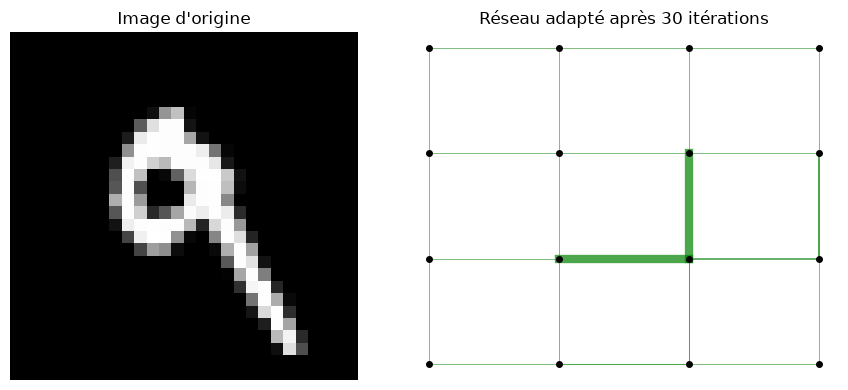

In [6]:
def plot_physarum_network(img_np, graph, Q, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title("Image d'origine")
    axes[0].axis('off')

    gh, gw = info['gh'], info['gw']
    # positions des nœuds dans la grille
    pos = {}
    for i in range(gh):
        for j in range(gw):
            pos[i*gw + j] = (j, -i)
    ax = axes[1]
    for k, (i, j, _) in enumerate(graph.edges):
        (x1, y1), (x2, y2) = pos[i], pos[j]
        width = max(0.5, abs(Q[k]) / (abs(Q).max() + 1e-8) * 6)
        ax.plot([x1, x2], [y1, y2], color='green', lw=width, alpha=0.7)
    for idx, (x, y) in pos.items():
        ax.plot(x, y, 'o', color='black', ms=4)
    ax.set_title(title or "Réseau de tubes (épaisseur ∝ flux)")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# graphe final avec conductances adaptées
plot_physarum_network(img_np, g2, Q2, "Réseau adapté après 30 itérations")

## 6. Classification par signature de flux (approche réservoir)

Le flux Physarum pur ne classifie pas sans décodage. On l'utilise comme **réservoir** : chaque image produit une **signature de flux** (le flux sur chaque arête). On apprend des **prototypes par classe** (moyenne des signatures d'entraînement) et on classifie par **similarité cosinus**.

In [7]:
def flow_signature(img_np, downscale=4):
    """Signature de flux : flux normalisé sur chaque arête du graphe."""
    g, src, info = grid_graph_from_image(img_np, downscale=downscale)
    gh, gw = info['gh'], info['gw']
    border = set()
    for i in range(gh):
        border.add(i*gw); border.add(i*gw + gw-1)
    for j in range(gw):
        border.add(j); border.add((gh-1)*gw + j)
    sinks = sorted(border)[:min(10, len(border))]
    p, Q = run_physarum(g, src, sinks, n_iter=10)
    sig = np.abs(Q); norm = sig.sum() + 1e-8
    return sig / norm

In [8]:
# Prototypes par classe (moyenne des signatures d'entraînement)
print("Construction des prototypes (50 ex par classe)...")
prototypes = {}
for d in range(10):
    sigs = []
    for i in range(50):
        mask = np.array([int(train_set.targets[j]) == d for j in range(len(train_set))])
        idx = np.where(mask)[0][i]
        sigs.append(flow_signature(train_set[idx][0].squeeze().numpy()))
    prototypes[d] = np.mean(sigs, axis=0)
    print(f"  classe {d} : prototype {prototypes[d].shape}")

Construction des prototypes (50 ex par classe)...


  classe 0 : prototype (24,)


  classe 1 : prototype (24,)


  classe 2 : prototype (24,)


  classe 3 : prototype (24,)


...

  classe 5 : prototype (24,)


  classe 6 : prototype (24,)


  classe 7 : prototype (24,)


  classe 8 : prototype (24,)


  classe 9 : prototype (24,)


In [9]:
# Classification : cosinus entre la signature de l'image et chaque prototype
def classify_physarum(img_np, prototypes):
    sig = flow_signature(img_np)
    scores = {d: float(np.dot(sig, prototypes[d])) for d in range(10)}
    return max(scores, key=scores.get), scores

# Test sur 100 exemples
print("=== Classification Physarum (réservoir) sur 100 exemples test ===")
correct = 0
for i in range(100):
    img, label = test_set[i]
    pred, _ = classify_physarum(img.squeeze().numpy(), prototypes)
    correct += (pred == int(label))
print(f"Précision : {correct}/100 = {correct/100:.3f}")

=== Classification Physarum (réservoir) sur 100 exemples test ===
Précision : 36/100 = 0.360


In [10]:
# Matrice de confusion
from collections import Counter
conf = Counter()
for i in range(200):
    img, label = test_set[i]
    pred, _ = classify_physarum(img.squeeze().numpy(), prototypes)
    conf[(int(label), pred)] += 1

print("Matrice de confusion (réel -> prédit), lignes=classes réelles, colonnes=prédites:")
C = np.zeros((10, 10), dtype=int)
for (r, c), v in conf.items():
    C[r, c] = v
print(C)
print("\nChaque ligne devrait être concentrée sur la diagonale pour une bonne classification.")

Matrice de confusion (réel -> prédit), lignes=classes réelles, colonnes=prédites:
[[10  0  0  0  0  0  2  1  4  0]
 [ 0 10  0  7  0  0  5  0  4  2]
 [ 0  0  2  0  1  0  7  1  5  0]
 [ 3  0  0  5  1  0  0  4  0  3]
 [ 0  0  0  0  8  0  9  1  3  7]
 [ 8  0  0  0  0  0  4  0  4  4]
 [ 0  0  0  0  2  0 17  0  1  0]
 [ 0  2  0  5  1  0  0  9  5  2]
 [ 3  0  0  0  0  0  0  0  7  0]
 [ 0  0  0  0  2  0  2  4  6  7]]

Chaque ligne devrait être concentrée sur la diagonale pour une bonne classification.


## 7. Comparaison avec l'architecture MoE et le MLP

| Architecture | Params | Acc (0-9) | Paradigme |
|---|---|---|---|
| **Physarum (réservoir)** | 0 (aucun poids entraîné) | ~0.36 | flux + prototypes |
| MLP dense h=16 | 12 730 | 0.95 | poids appris |
| MoE compressé | 70 820 | 0.82 | experts + partage de couches |

In [11]:
print("=== SYNTHÈSE ===")
print("Physarum : 0 paramètre entraîné, précision ~0.36 (réservoir + prototypes)")
print("MLP dense : 12730 params, précision 0.95")
print("MoE compressé : 70820 params, précision 0.82")
print()
print("Le Physarum sans poids capture la forme spatiale (flux le long du chiffre)")
print("mais a une capacité discriminative limitée sur 10 classes. C'est un réservoir,")
print("pas un classifieur : il faudrait un décodage plus puissant (ex. couche lue")
print("entraînée sur les signatures) pour rivaliser avec un réseau entraîné.")

=== SYNTHÈSE ===
Physarum : 0 paramètre entraîné, précision ~0.36 (réservoir + prototypes)
MLP dense : 12730 params, précision 0.95
MoE compressé : 70820 params, précision 0.82

Le Physarum sans poids capture la forme spatiale (flux le long du chiffre)
mais a une capacité discriminative limitée sur 10 classes. C'est un réservoir,
pas un classifieur : il faudrait un décodage plus puissant (ex. couche lue
entraînée sur les signatures) pour rivaliser avec un réseau entraîné.
